<a href="https://colab.research.google.com/github/JeonYeongwoo/2026-1_CV/blob/main/3%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 목표


**손실 함수, 활성화 함수, 최적화 알고리즘**이 학습 결과에 미치는 영향을 구현과 실험을 통해 **정량적**으로 분석
실험 결과를 바탕으로 성능 비교 + 실험결과 분석 보고서 작성


In [ ]:
# PyTorch 설치 여부 확인
!pip install torch torchvision

In [ ]:
# 기본 설치 내용

import torch  # torch : PyTorch의 핵심 패키지
import torch.nn as nn  # torch.nn : 신경망 모델의 구조와 층(layer)을 정의하는 모듈
import torch.optim as optim  # torch.optim : 최적화(학습 알고리즘) 기능 제공
import torchvision.datasets as dsets   # torchvision.datasets : 표준 이미지 데이터셋(MNIST 등)을 간편하게 제공
import torchvision.transforms as transforms  # transforms : 이미지 데이터를 신경망에 입력하기 전에 전처리 및 변환하는 기능
from torch.utils.data import DataLoader     # DataLoader : 데이터를 미니배치로 나누고 셔플링하여 학습을 쉽게 하는 도구

# GPU 사용 가능 여부
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device) # cuda 출력되면 GPU 활성화 완료

cuda


# 2. 실험 구성

## 1) 기본 **네트워크 구조** (예시) :  다음과 같은 MLP 구조 사용 - 예시 일 뿐 변경 가능함.

(더 깊은 Layer (512 → 256 → 128 → Output)나 Shallow Layer(128 → 64 → Output)도 추가 실험해 보면 최적화 기법이 학습 속도에 미치는 영향이 더 잘 보일 것임)




    
    model = nn.Sequential(
      nn.Linear(input_size, 256),   # 입력 → 첫 번째 은닉층 (input_size → 256)
      nn.ReLU(),                              # 활성화 함수 (ReLU)
      nn.Linear(256, 128),              # 두 번째 은닉층 (256 → 128)
      nn.ReLU(),                              # 활성화 함수 (ReLU)
      nn.Linear(128, num_classes)   # 출력층 (128 → 클래스 개수)
    )


<br>

## 2) **데이터셋** 선택 : 각 실험에 적합한 데이터셋 사용


 실험              추천 데이터셋                                   설명
---------------------------------------------------------------------------------------------------------------------------------
실험A  **Fashion-MNIST, Digits Dataset(scikit-learn)**     28x28 흑백 이미지 **(Fashion-MNIST), 8x8 숫자 이미지 (Digits)

실험 B **make_moons, make_circlest(scikit-learn)**       2D 비선형 분류 문제, Dead ReLU 및 학습 경계 시각화에 유리

실험 C **Fashion-MNIST, Digits Dataset**                        Optimizer 성능 차이를 분석하기에 적합

 <br>

## 3)  활용 **기술 제한 및 구현 조건**

### A. 프레임워크 사용 범위
   - PyTorch 또는 TensorFlow 사용 가능
   - 모델은 **nn.Module** 또는 **tf.keras.Model**을 통해 구성할 수 있음
   - 학습 루프는 **for epoch in range(...)** 형태로 직접 작성할 것

<br>

### B. 자동 미분 (autograd) 사용 가능
   - **backward() (PyTorch)** 또는 **tape.gradient()** (TensorFlow) 사용 가능
   - 단, 손실함수와 활성화함수는 **명시적으로 설정하고 변경**해야 함

  예시) loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

<br>

### C.  손실 함수, 활성화 함수, 최적화기법을 실험별로 수동 설정 및 교체 가능하도록 구현
   - **loss_fn = ...** 형식으로 명확히 설정
   - **optimizer = torch.optim.Adam(...)** 등 명확히 기술
   - 각 실험에서 **이 구성 요소를 바꿔가며 성능 차이를 비교**해야 함

<br>

### [구현 조건] ###
  - 실험 A, B, C에 **model.eval()과 with torch.no_grad()** 활용
  - 모델 성능 차이가 잘 드러나는 학습률 / 에폭 수 사용

<br>

### Learning Rate  가이드 ###
  - SGD(0.01~0.1) : 단순 경사 하강법이므로 비교적 큰 학습률을 사용
  - SGD+Momentum(0.01~0.05) : SGD보다 빠르게 수렴하지만, 진동을 줄이기 위해 약간 낮춤
  - Adam(0.001~0.01) : Adaptive Learning Rate를 사용하므로 작은 값이 효과적

### 에폭수 가이드 ###
  - Fashion-MNIST 20 ~ 50
  - Digits Dataset 20 ~ 50
  - make_moons 200 ~ 500
  - CIFAR-10 50 ~ 100

### 에폭 수 설정 가이드 ###
  - 실험 전에 Baseline Epoch 설정
  - 적절한 시점에 학습 종료
  - 수렴 속도가 느리면 Learning Rate Decay 추가 적용

# Baseline from code uploaded in LMS

# 3. 실험 설계 및 실행

## [실험 A] **손실 함수** 비교 : CrossEntropy Loss vs MSE Loss (with softmax)

### 1) 실험 목표
  -  **MSE**와 **CrossEntropy**가 **학습 성능**에 미치는 차이 분석
  - 학습 곡선의 **수렴 속도, 정확도, loss 안정성** 비교

### 2) 추천 데이터셋 :  Fashion-MNIST, Digits Dataset

### 3) 실험 조건
  - 동일한 네트워크 구조 및 optimizer 하에 **손실함수**만 변경
  - **MSE Loss** 사용 시 **softmax**를 **출력층에 명시적**으로 적용. **CrossEntropy Loss는내부적으로 softmax** 포함

예시) # MSE Loss 사용 시
   loss_fn = nn.MSELoss()
   outputs = torch.softmax(model(inputs), dim=1)

### 4) 분석 포인트
  - MSE 사용 시 **Gradient Vanishing** 문제 분석
  - CrossEntropy의 빠른 **수렴 속도와 안정성** 확인
  - **최종 정확도 차이, 학습 곡선** 비교

In [ ]:
# 실험 A 하이퍼파라미터

# 하이퍼 파라미터 설정 : 모델의 구조와 학습 조건을 정의하는 핵심 변수들.
input_size = 784      # MNIST 이미지 크기 (28*28 픽셀)
hidden_size1 = 512     # 은닉층의 노드 수
hidden_size2 = 256
hidden_size3 = 128
num_classes = 10      # 숫자 클래스 (0~9)

num_epochs = 50       # 학습 횟수
batch_size = 128      # 한 번에 처리하는 데이터 개수
learning_rate = 0.001 # 학습률 (너무 크면 발산, 너무 작으면 느린 학습)

데이터 로드

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 전처리 정의: 이미지를 텐서로 변환하고 정규화 (평균 0.5, 표준편차 0.5)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Fashion-MNIST 데이터셋 다운로드 및 로드
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [ ]:
# 2) 데이터 로더
batch_size = 64

# 3. DataLoader 설정
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")

학습 데이터 개수: 60000
테스트 데이터 개수: 10000


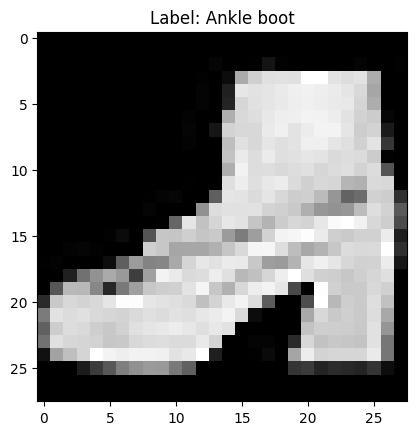

In [ ]:
# 3) 데이터 확인
import matplotlib.pyplot as plt

# 첫 번째 배치 데이터 가져오기
images, labels = next(iter(train_loader))

# 클래스 레이블 매핑
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 이미지 시각화
plt.imshow(images[0].numpy().squeeze(), cmap='gray')
plt.title(f'Label: {classes[labels[0]]}')
plt.show()

실험

In [ ]:
# A-1 번 실험 : MSE 사용 방법

# 모델 정의
# 신경망 구조: 입력층(784개) → 은닉층(512개, ReLU) → 은닉층(256개, ReLU) → 은닉층(128, ReLU) →  출력층(10개)

class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden2, hidden3)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.fc4(x)
        return x

model = MLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)

# 손실함수 및 옵티마이저 정의
loss_fn = nn.MSELoss() # 이 부분을 변경. MES <-> CrossEntropy
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# A-1번 실험 모델 학습

# ----- 추가 : 시각화용 --># 결과를 저장할 리스트 초기화 -----------
history = {
    'train_loss': [],
    'test_accuracy': []
}
# -------------------------------------------------------------------

for epoch in range(num_epochs):  # 매 epoch마다 훈련 데이터를 모델에 입력하고 손실을 계산
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        # 순전파
        outputs = model(images)

        # 2. MSE를 위해 Softmax를 명시적으로 적용 (확률값 0~1 사이로 변환)
        outputs_softmax = torch.softmax(outputs, dim=1)

        # 3. 정답 레이블을 One-hot 벡터로 변환 (예: 3 -> [0,0,0,1,0,0,0,0,0,0])
        # labels_one_hot의 데이터 타입은 float이어야 MSE 계산이 가능합니다.
        labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=10).float()

        # 4. Loss 계산 (Softmax 결과와 One-hot 정답 비교)
        loss = loss_fn(outputs_softmax, labels_one_hot)

        # 5. 역전파 및 최적화 : 역전파(backpropagation)를 통해 모델의 가중치를 업데이트
        optimizer.zero_grad()  # 이전 기울기 초기화
        loss.backward()        # 역전파를 통한 기울기 계산
        optimizer.step()       # 가중치 업데이트

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader) # 평균 손실을 계산하여 학습 상황을 확인함.

    # 학습이 완료된 모델의 성능(정확도)을 평가
    # 검증 데이터셋에서 평가 : 매 epoch이 끝난 후 테스트 데이터를 통해 정확도를 측정
    model.eval() # 모델 평가 모드(model.eval())를 활성화하여 평가 단계에서 dropout, batch normalization 등은 비활성화함
    correct = 0 # correct: 정확히 맞춘 데이터 개수
    total = 0 # total: 전체 데이터 개수
    with torch.no_grad():  # PyTorch에서는 모델 평가 시 기울기(gradient)를 계산하지 않음
        for images, labels in test_loader: # 미리 준비된 테스트 데이터를 가져와 반복적으로 평가. 한 번 반복할 때마다 images(이미지 배치)와 labels(정답 레이블)을 불러옴.
            images = images.reshape(-1, 28*28).to(device) # MNIST 데이터의 이미지 크기(28×28)를 1차원 형태로 펼쳐 모델 입력 형태에 맞춤.
            labels = labels.to(device) # 정답 레이블도 GPU로 이동시켜 모델과 같은 위치에서 비교할 수 있도록 함.
            outputs = model(images) # 준비한 이미지를 모델에 넣어 예측 결과를 얻음. outputs에는 각 클래스(0~9)에 대한 확률 형태의 값이 저장됨.
            _, predicted = torch.max(outputs.data, 1) # 모델이 출력한 결과(outputs)에서 가장 높은 값을 가진 클래스(숫자)를 찾음. predicted 변수에 예측한 클래스(숫자 0~9)를 저장함.
            total += labels.size(0) # 현재 처리한 미니 배치(mini-batch)의 데이터 수를 누적하여 전체 데이터 개수를 계산함.
            correct += (predicted == labels).sum().item() # 모델이 예측한 클래스(predicted)와 정답(labels)을 비교하여 맞힌 개수를 셈. .sum()을 통해 맞춘 개수를 모두 합하고 .item()으로 정수 형태로 변환하여 correct에 더함.

    accuracy = 100 * correct / total  # 정확도(%) = (맞춘 데이터 수 ÷ 전체 데이터 수) × 100

    history['train_loss'].append(avg_loss)
    history['test_accuracy'].append(accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Accuracy: {accuracy:.2f}%')

# 최종 평가 : 최종 epoch이 끝난 후의 테스트 데이터 정확도를 출력함.
print(f'최종 테스트 정확률: {accuracy:.2f}%')

Epoch [1/50], Loss: 0.0269, Validation Accuracy: 83.96%
Epoch [2/50], Loss: 0.0202, Validation Accuracy: 84.08%
Epoch [3/50], Loss: 0.0186, Validation Accuracy: 86.16%
Epoch [4/50], Loss: 0.0173, Validation Accuracy: 86.85%
Epoch [5/50], Loss: 0.0164, Validation Accuracy: 87.29%
Epoch [6/50], Loss: 0.0156, Validation Accuracy: 86.82%
Epoch [7/50], Loss: 0.0149, Validation Accuracy: 88.00%
Epoch [8/50], Loss: 0.0143, Validation Accuracy: 87.99%
Epoch [9/50], Loss: 0.0139, Validation Accuracy: 87.60%
Epoch [10/50], Loss: 0.0133, Validation Accuracy: 86.53%
Epoch [11/50], Loss: 0.0129, Validation Accuracy: 88.49%
Epoch [12/50], Loss: 0.0125, Validation Accuracy: 88.81%
Epoch [13/50], Loss: 0.0120, Validation Accuracy: 88.25%
Epoch [14/50], Loss: 0.0116, Validation Accuracy: 87.97%
Epoch [15/50], Loss: 0.0114, Validation Accuracy: 88.10%
Epoch [16/50], Loss: 0.0109, Validation Accuracy: 88.92%
Epoch [17/50], Loss: 0.0106, Validation Accuracy: 89.04%
Epoch [18/50], Loss: 0.0105, Validation 

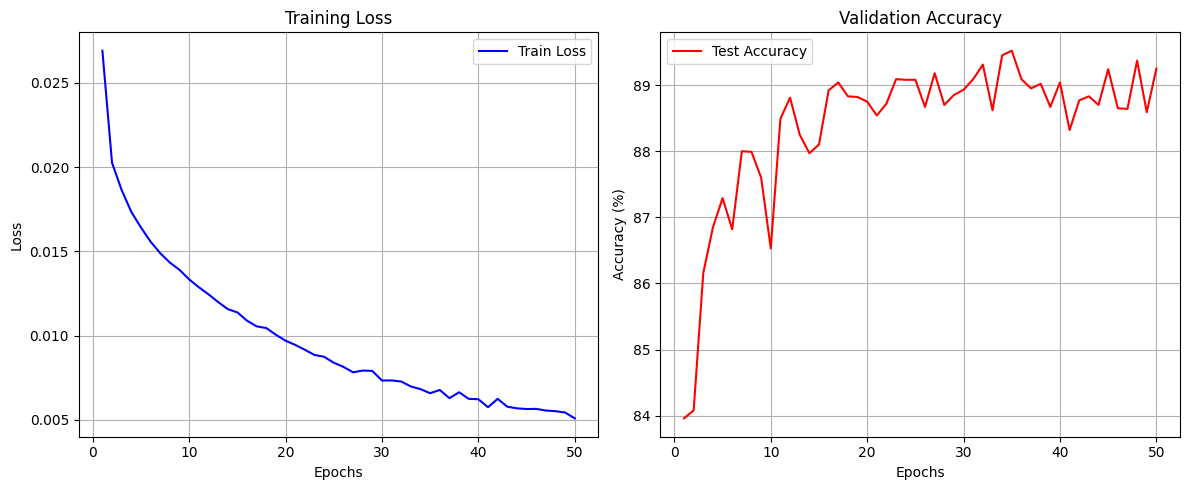

In [ ]:
import matplotlib.pyplot as plt

# 시각화 설정
plt.figure(figsize=(12, 5))

# 1. Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history['train_loss'], label='Train Loss', color='blue')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history['test_accuracy'], label='Test Accuracy', color='red')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# A-2 번 실험 : MSE 사용 방법

# 모델 정의
# 신경망 구조: 입력층(784개) → 은닉층(512개, ReLU) → 은닉층(256개, ReLU) → 은닉층(128, ReLU) →  출력층(10개)

class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden2, hidden3)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.fc4(x)
        return x

model = MLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)

# 손실함수 및 옵티마이저 정의
loss_fn = nn.CrossEntropyLoss() # PyTorch의 CrossEntropyLoss()는 내부적으로 자동으로 softmax 계산까지 진행
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# A-2번 실험 모델 학습 -> cross entropy

# ----- 추가 : 시각화용 --># 결과를 저장할 리스트 초기화 -----------
history = {
    'train_loss': [],
    'test_accuracy': []
}
# -------------------------------------------------------------------


# 모델 학습
for epoch in range(num_epochs):  # 매 epoch마다 훈련 데이터를 모델에 입력하고 손실을 계산
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        # 순전파
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # 역전파 및 최적화 : 역전파(backpropagation)를 통해 모델의 가중치를 업데이트
        optimizer.zero_grad()  # 이전 기울기 초기화
        loss.backward()        # 역전파를 통한 기울기 계산
        optimizer.step()       # 가중치 업데이트

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader) # 평균 손실을 계산하여 학습 상황을 확인함.

    # 학습이 완료된 모델의 성능(정확도)을 평가
    # 검증 데이터셋에서 평가 : 매 epoch이 끝난 후 테스트 데이터를 통해 정확도를 측정
    model.eval() # 모델 평가 모드(model.eval())를 활성화하여 평가 단계에서 dropout, batch normalization 등은 비활성화함
    correct = 0 # correct: 정확히 맞춘 데이터 개수
    total = 0 # total: 전체 데이터 개수
    with torch.no_grad():  # PyTorch에서는 모델 평가 시 기울기(gradient)를 계산하지 않음
        for images, labels in test_loader: # 미리 준비된 테스트 데이터를 가져와 반복적으로 평가. 한 번 반복할 때마다 images(이미지 배치)와 labels(정답 레이블)을 불러옴.
            images = images.reshape(-1, 28*28).to(device) # MNIST 데이터의 이미지 크기(28×28)를 1차원 형태로 펼쳐 모델 입력 형태에 맞춤.
            labels = labels.to(device) # 정답 레이블도 GPU로 이동시켜 모델과 같은 위치에서 비교할 수 있도록 함.
            outputs = model(images) # 준비한 이미지를 모델에 넣어 예측 결과를 얻음. outputs에는 각 클래스(0~9)에 대한 확률 형태의 값이 저장됨.
            _, predicted = torch.max(outputs.data, 1) # 모델이 출력한 결과(outputs)에서 가장 높은 값을 가진 클래스(숫자)를 찾음. predicted 변수에 예측한 클래스(숫자 0~9)를 저장함.
            total += labels.size(0) # 현재 처리한 미니 배치(mini-batch)의 데이터 수를 누적하여 전체 데이터 개수를 계산함.
            correct += (predicted == labels).sum().item() # 모델이 예측한 클래스(predicted)와 정답(labels)을 비교하여 맞힌 개수를 셈. .sum()을 통해 맞춘 개수를 모두 합하고 .item()으로 정수 형태로 변환하여 correct에 더함.

    accuracy = 100 * correct / total  # 정확도(%) = (맞춘 데이터 수 ÷ 전체 데이터 수) × 100

    history['train_loss'].append(avg_loss)
    history['test_accuracy'].append(accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Accuracy: {accuracy:.2f}%')

# 최종 평가 : 최종 epoch이 끝난 후의 테스트 데이터 정확도를 출력함.
print(f'최종 테스트 정확률: {accuracy:.2f}%')

Epoch [1/50], Loss: 0.5042, Validation Accuracy: 83.94%
Epoch [2/50], Loss: 0.3725, Validation Accuracy: 85.64%
Epoch [3/50], Loss: 0.3324, Validation Accuracy: 85.86%
Epoch [4/50], Loss: 0.3067, Validation Accuracy: 86.42%
Epoch [5/50], Loss: 0.2880, Validation Accuracy: 87.46%
Epoch [6/50], Loss: 0.2717, Validation Accuracy: 87.63%
Epoch [7/50], Loss: 0.2537, Validation Accuracy: 87.83%
Epoch [8/50], Loss: 0.2427, Validation Accuracy: 88.19%
Epoch [9/50], Loss: 0.2306, Validation Accuracy: 88.01%
Epoch [10/50], Loss: 0.2202, Validation Accuracy: 88.51%
Epoch [11/50], Loss: 0.2101, Validation Accuracy: 88.71%
Epoch [12/50], Loss: 0.1991, Validation Accuracy: 89.35%
Epoch [13/50], Loss: 0.1905, Validation Accuracy: 88.13%
Epoch [14/50], Loss: 0.1796, Validation Accuracy: 88.82%
Epoch [15/50], Loss: 0.1749, Validation Accuracy: 88.43%
Epoch [16/50], Loss: 0.1633, Validation Accuracy: 88.94%
Epoch [17/50], Loss: 0.1570, Validation Accuracy: 87.23%
Epoch [18/50], Loss: 0.1512, Validation 

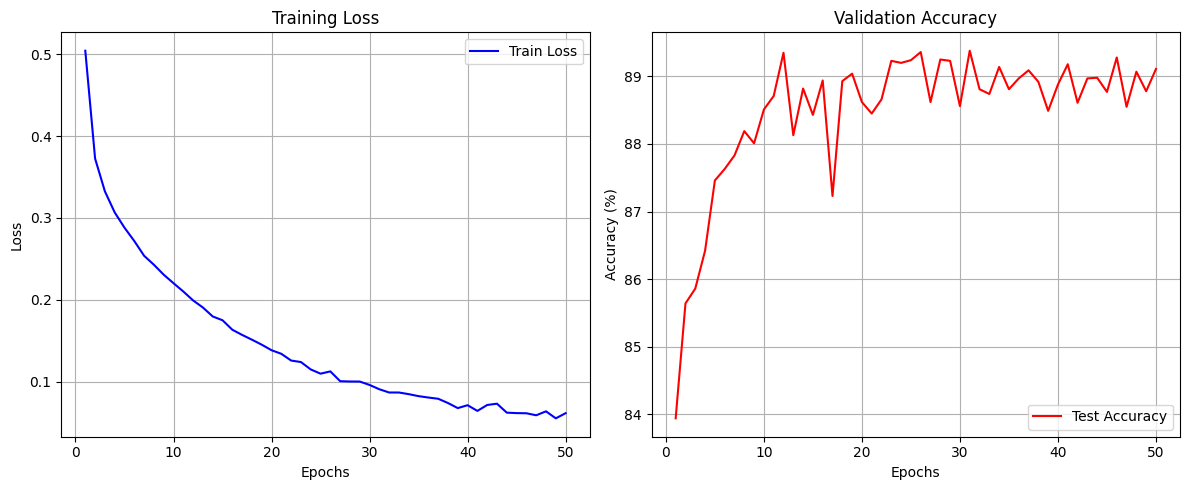

In [ ]:
import matplotlib.pyplot as plt

# 시각화 설정
plt.figure(figsize=(12, 5))

# 1. Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history['train_loss'], label='Train Loss', color='blue')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history['test_accuracy'], label='Test Accuracy', color='red')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## [실험 B] **활성화 함수** 비교 :  ReLU vs LeakyReLU vs Sigmoid

### 1) 실험 목표
  - ReLU, LeakyReLU, Sigmoid가 학습에 미치는 영향을 분석
  - **Dead ReLU 발생 유도** 및 **LeakyReLU의 완화 효과** 확인

### 2) 추천 데이터셋 : make_moons, make_circles

### 3) 실험 조건
  - **동일 네트워크 및 손실함수(CrossEntropy), Optimizer(Adam 또는 SGD)**
  - **weight 초기값**을 std=0.01 등 **작게** 설정하여 dead neuron 상황 유도

### 4) 분석 포인트
  - **Layer별 출력값 시각화** (matplotlib 사용)
  - **Sigmoid는 vanishing gradient** 발생 → **학습 정체** 확인
  - **Dead ReLU 발생 시 어떤 지표가 정체**되는지 분석
  - **Dead ReLU가 발생한 neuron 비율** 측정 → **히트맵** 시각화
  - **LeakyReLU**가 Dead ReLU 문제를 **얼마나 완화**하는지 시각적 분석

데이터 로드 및 하이퍼패러미터 설정

In [ ]:
# 실험B 하이퍼 파라미터
input_size = 2        # [x, y] 좌표이므로 2
num_classes = 2       # 이진 분류이므로 2
hidden_size1 = 512  # 첫 번째 은닉층의 뉴런 수
hidden_size2 = 256   # 두 번째 은닉층의 뉴런 수
hidden_size3 = 128   # 세 번째 은닉층의 뉴런 수
batch_size = 128     # 한 번에 처리하는 데이터의 개수
num_epochs = 200
learning_rate = 0.1   # 일부러 큰 lr을 주어 Dead ReLU 유도


In [ ]:
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import torch

# 1. 데이터 생성 및 학습/테스트 분할
X, y = make_moons(n_samples=1200, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Tensor 변환 (입력은 Float, 레이블은 Long)
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

# 3. 로더 정의 (이름을 기존 학습 루프와 똑같이 맞춰줍니다)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



In [ ]:
# dead_relu 시각화 위한 함수
def visualize_dead_relu(model, test_loader):
    model.eval()

    layer_info = {
        'l1': (16, 32),  # 512
        'l2': (16, 16),  # 256
        'l3': (8, 16)    # 128
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    with torch.no_grad():
        for idx, (layer_name, grid_shape) in enumerate(layer_info.items()):
            all_activations = []

            for inputs, _ in test_loader:
                inputs = inputs.to(device)
                model(inputs)

                activation = getattr(model, layer_name)
                all_activations.append(activation.cpu().numpy())

            concat_activation = np.concatenate(all_activations, axis=0)

            dead_neurons_mask = (concat_activation <= 0).all(axis=0)
            dead_ratio = np.mean(dead_neurons_mask)

            sns.heatmap(
                dead_neurons_mask.reshape(grid_shape),
                cmap='Reds',
                cbar=True,
                linewidths=0.5,
                ax=axes[idx]
            )

            axes[idx].set_title(f'{layer_name} Dead ReLU\nDead Ratio: {dead_ratio:.2%}')
            axes[idx].set_xlabel('Neuron Index X')
            axes[idx].set_ylabel('Neuron Index Y')

    plt.tight_layout()
    plt.show()

히트맵 출력 위한 임포

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Relu

In [ ]:
# B-1 번 실험 : ReLU 사용

# 신경망 모델 정의(MLP)
# 신경망 구조: 입력층(784개) → 은닉층(512개, ReLU) → 은닉층(256개, ReLU) -> 은닉층(128개, ReLU) -> output
class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(DeepMLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, hidden3)
        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
        self.l1 = self.relu(self.fc1(x))
        self.l2 = self.relu(self.fc2(self.l1))
        self.l3 = self.relu(self.fc3(self.l2))

      # 추후 레이어별 기여도를 뽑기 위함.  (activation값 * gradient를 계산하여금 기여도를 계산).
        if self.l1.requires_grad:
            self.l1.retain_grad()
        if self.l2.requires_grad:
            self.l2.retain_grad()
        if self.l3.requires_grad:
            self.l3.retain_grad()

        x = self.fc4(self.l3)
        return x

In [ ]:
# 모델 및 최적화 알고리즘 설정
# 모델을 GPU로 이동(.to(device))시켜 빠르게 학습할 수 있도록 함.
model = DeepMLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)

# 손실함수 및 옵티마이저 설정
loss_fn = nn.CrossEntropyLoss()  # 내부적으로 log(softmax()) 계산을 포함하고 있음.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

In [ ]:
# 공통과제 3번 위해 추가적으로 실습 진행 -> 초기, 중간, 후기 activation 확인

activation_snapshots = {
    'early': {'l1': None, 'l2': None, 'l3': None},
    'middle': {'l1': None, 'l2': None, 'l3': None},
    'late': {'l1': None, 'l2': None, 'l3': None}
}

snapshot_epochs = {
    1: 'early',
    num_epochs // 2: 'middle',
    num_epochs: 'late'
}

In [ ]:
# 모델 학습
# 전체 데이터셋을 반복(epoch)하면서 학습 진행

# 학습 정체 및 히트맵 출력을 위함
history = {'train_loss': [], 'test_accuracy': []}

contribution_history = {
    'l1': [],
    'l2': [],
    'l3': []
}


# 여기부터 모델 학습을 위한 epoch
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    # contribution 정도 계산을 위함
    epoch_contrib_l1 = 0
    epoch_contrib_l2 = 0
    epoch_contrib_l3 = 0
    batch_count = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 순전파
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # 역전파 및 최적화
        optimizer.zero_grad()
        loss.backward()

        # -------------------------------
        # activation × gradient 계산 위치
        # -------------------------------
        with torch.no_grad():
            contrib_l1 = torch.abs(model.l1 * model.l1.grad).mean().item()
            contrib_l2 = torch.abs(model.l2 * model.l2.grad).mean().item()
            contrib_l3 = torch.abs(model.l3 * model.l3.grad).mean().item()

            epoch_contrib_l1 += contrib_l1
            epoch_contrib_l2 += contrib_l2
            epoch_contrib_l3 += contrib_l3
            batch_count += 1

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    avg_contrib_l1 = epoch_contrib_l1 / batch_count
    avg_contrib_l2 = epoch_contrib_l2 / batch_count
    avg_contrib_l3 = epoch_contrib_l3 / batch_count

    contribution_history['l1'].append(avg_contrib_l1)
    contribution_history['l2'].append(avg_contrib_l2)
    contribution_history['l3'].append(avg_contrib_l3)

    # 검증 데이터셋 평가
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f'Epoch [{epoch+1}/{num_epochs}], '
        f'Loss: {avg_loss:.4f}, '
        f'Accuracy: {accuracy:.2f}%, '
        f'C1: {avg_contrib_l1:.6f}, '
        f'C2: {avg_contrib_l2:.6f}, '
        f'C3: {avg_contrib_l3:.6f}'
    )

    history['train_loss'].append(avg_loss)
    history['test_accuracy'].append(accuracy)

    # -------------------------------
    # 초반 / 중반 / 후반 Activation 저장
    # -------------------------------
    if (epoch + 1) in snapshot_epochs:
        phase = snapshot_epochs[epoch + 1]

        model.eval()
        all_l1 = []
        all_l2 = []
        all_l3 = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)

                outputs = model(images)

                all_l1.append(model.l1.detach().cpu())
                all_l2.append(model.l2.detach().cpu())
                all_l3.append(model.l3.detach().cpu())

        activation_snapshots[phase]['l1'] = torch.cat(all_l1, dim=0)
        activation_snapshots[phase]['l2'] = torch.cat(all_l2, dim=0)
        activation_snapshots[phase]['l3'] = torch.cat(all_l3, dim=0)

        print(f"{phase} activation saved at epoch {epoch+1}")

    scheduler.step(avg_loss)



Epoch [1/200], Loss: 29.5415, Accuracy: 95.00%, C1: 0.001808, C2: 0.004813, C3: 0.013986
early activation saved at epoch 1
Epoch [2/200], Loss: 0.0737, Accuracy: 99.17%, C1: 0.000029, C2: 0.000027, C3: 0.000025
Epoch [3/200], Loss: 0.0399, Accuracy: 92.50%, C1: 0.000021, C2: 0.000022, C3: 0.000021
Epoch [4/200], Loss: 0.1784, Accuracy: 98.75%, C1: 0.000063, C2: 0.000072, C3: 0.000184
Epoch [5/200], Loss: 0.0565, Accuracy: 97.92%, C1: 0.000023, C2: 0.000023, C3: 0.000050
Epoch [6/200], Loss: 0.0361, Accuracy: 99.58%, C1: 0.000017, C2: 0.000012, C3: 0.000030
Epoch [7/200], Loss: 0.0128, Accuracy: 99.58%, C1: 0.000004, C2: 0.000004, C3: 0.000008
Epoch [8/200], Loss: 1.0017, Accuracy: 92.50%, C1: 0.000192, C2: 0.000255, C3: 0.000689
Epoch [9/200], Loss: 0.1291, Accuracy: 100.00%, C1: 0.000028, C2: 0.000045, C3: 0.000208
Epoch [10/200], Loss: 0.1391, Accuracy: 98.75%, C1: 0.000058, C2: 0.000055, C3: 0.000128
Epoch [11/200], Loss: 0.0861, Accuracy: 100.00%, C1: 0.000025, C2: 0.000032, C3: 0.

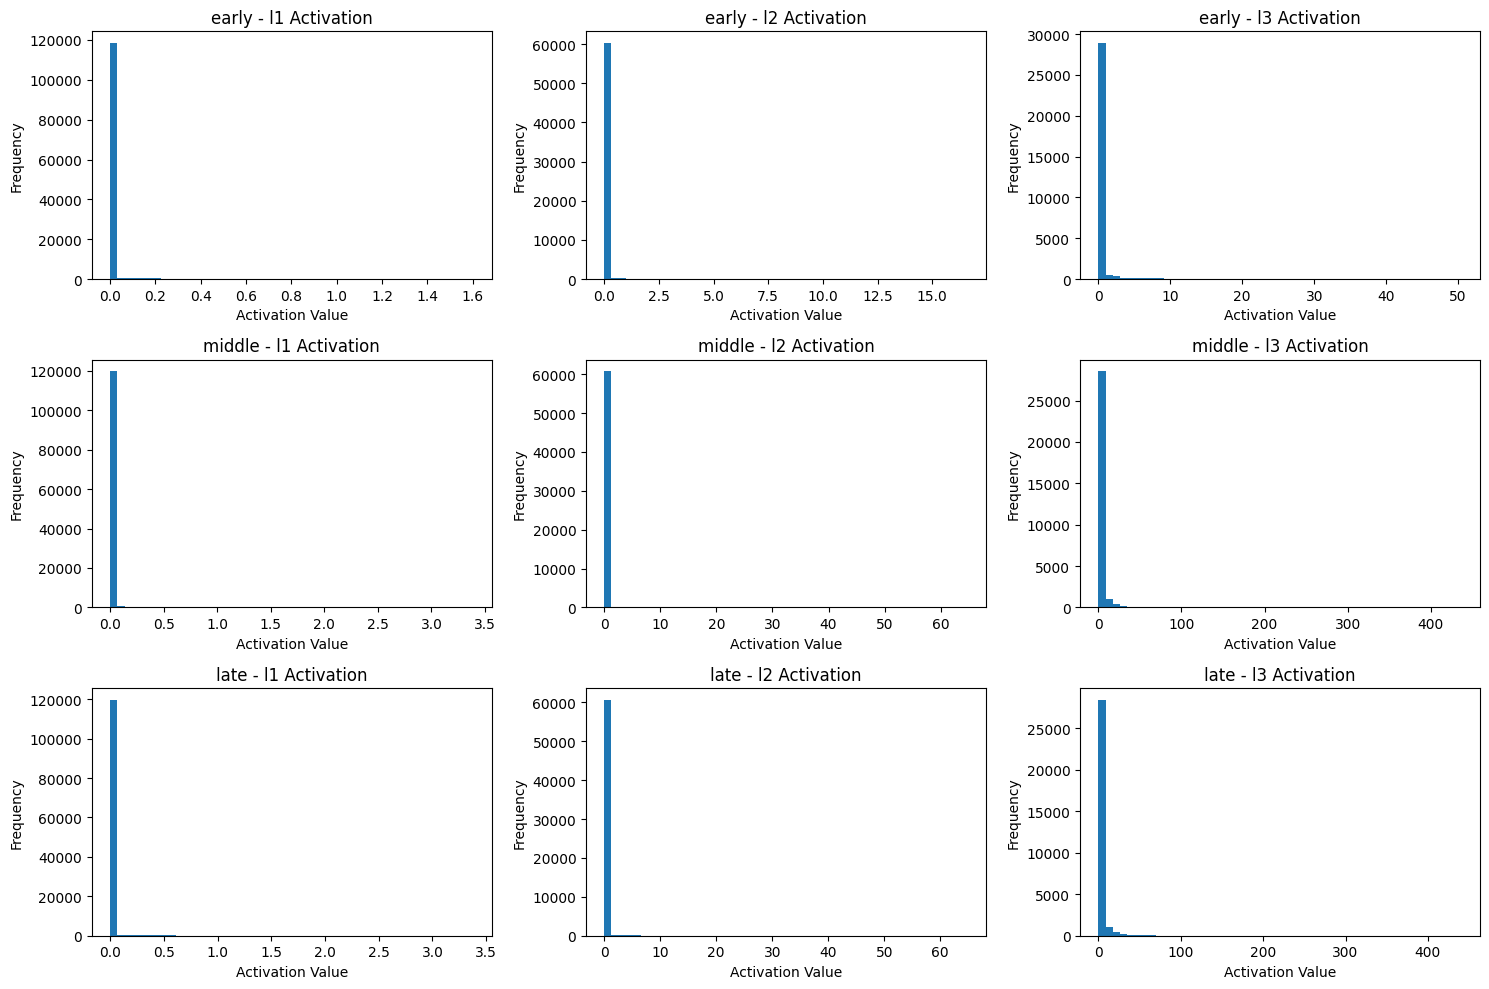

In [ ]:
# 공통과제 3번 위함 -> layer별 초기, 중기, 후기의 activation 확인
import matplotlib.pyplot as plt

phases = ['early', 'middle', 'late']
layers = ['l1', 'l2', 'l3']

plt.figure(figsize=(15, 10))

plot_idx = 1

for phase in phases:
    for layer in layers:
        act = activation_snapshots[phase][layer]

        plt.subplot(3, 3, plot_idx)
        plt.hist(act.numpy().flatten(), bins=50)
        plt.title(f'{phase} - {layer} Activation')
        plt.xlabel('Activation Value')
        plt.ylabel('Frequency')

        plot_idx += 1

plt.tight_layout()
plt.show()

In [ ]:
# Layer별 출력값 시각화
# 학습이 끝난 후, test 데이터 중 일부를 모델에 넣고
# 각 은닉층의 activation 값을 matplotlib으로 시각화

import matplotlib.pyplot as plt

model.eval()

# test_loader에서 배치 하나 가져오기
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

# forward 과정에서 저장된 layer 출력값 가져오기
l1_output = model.l1.detach().cpu()
l2_output = model.l2.detach().cpu()
l3_output = model.l3.detach().cpu()

print("Layer 1 output shape:", l1_output.shape)
print("Layer 2 output shape:", l2_output.shape)
print("Layer 3 output shape:", l3_output.shape)

Layer 1 output shape: torch.Size([32, 512])
Layer 2 output shape: torch.Size([32, 256])
Layer 3 output shape: torch.Size([32, 128])


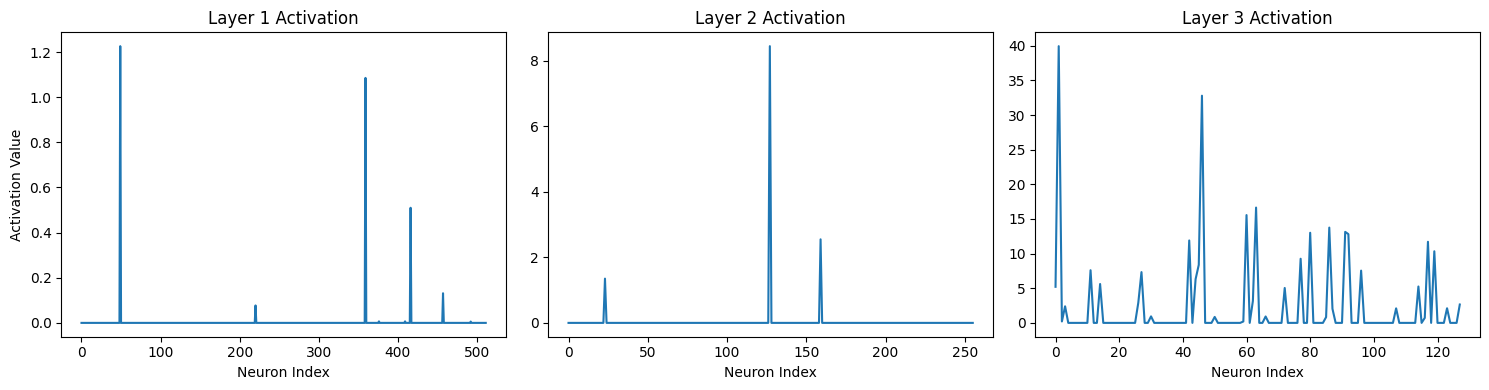

In [ ]:
# 하나의 샘플에 대한 Layer별 출력값 시각화
sample_idx = 0

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(l1_output[sample_idx].numpy())
plt.title("Layer 1 Activation")
plt.xlabel("Neuron Index")
plt.ylabel("Activation Value")

plt.subplot(1, 3, 2)
plt.plot(l2_output[sample_idx].numpy())
plt.title("Layer 2 Activation")
plt.xlabel("Neuron Index")

plt.subplot(1, 3, 3)
plt.plot(l3_output[sample_idx].numpy())
plt.title("Layer 3 Activation")
plt.xlabel("Neuron Index")

plt.tight_layout()
plt.show()

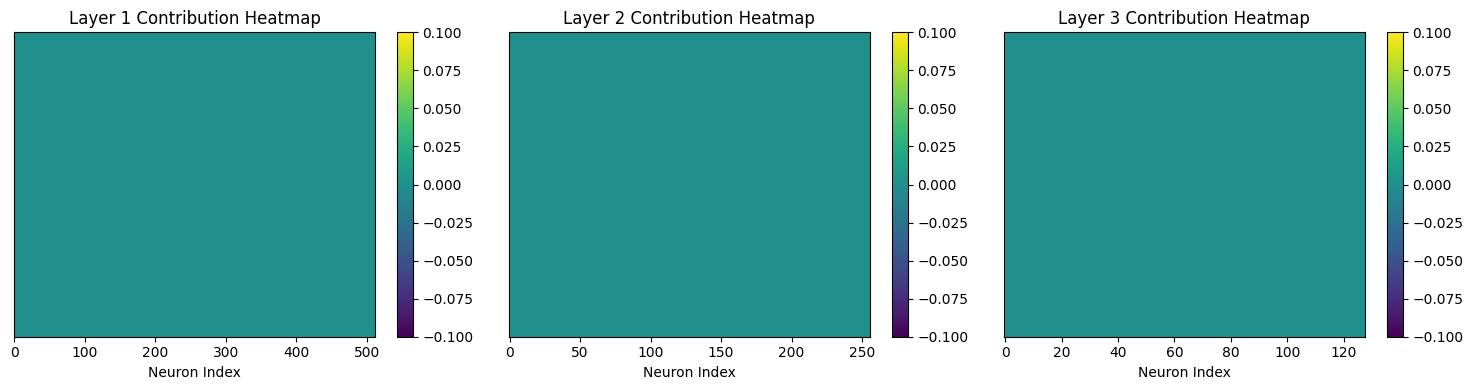

In [ ]:
# 레이어 별 기여도 히트맵 출력

model.train()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = loss_fn(outputs, labels)

optimizer.zero_grad()
loss.backward()

contrib_l1 = torch.abs(model.l1 * model.l1.grad).detach().cpu()
contrib_l2 = torch.abs(model.l2 * model.l2.grad).detach().cpu()
contrib_l3 = torch.abs(model.l3 * model.l3.grad).detach().cpu()

sample_idx = 0

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(contrib_l1[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 1 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(contrib_l2[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 2 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(contrib_l3[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 3 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.tight_layout()
plt.show()

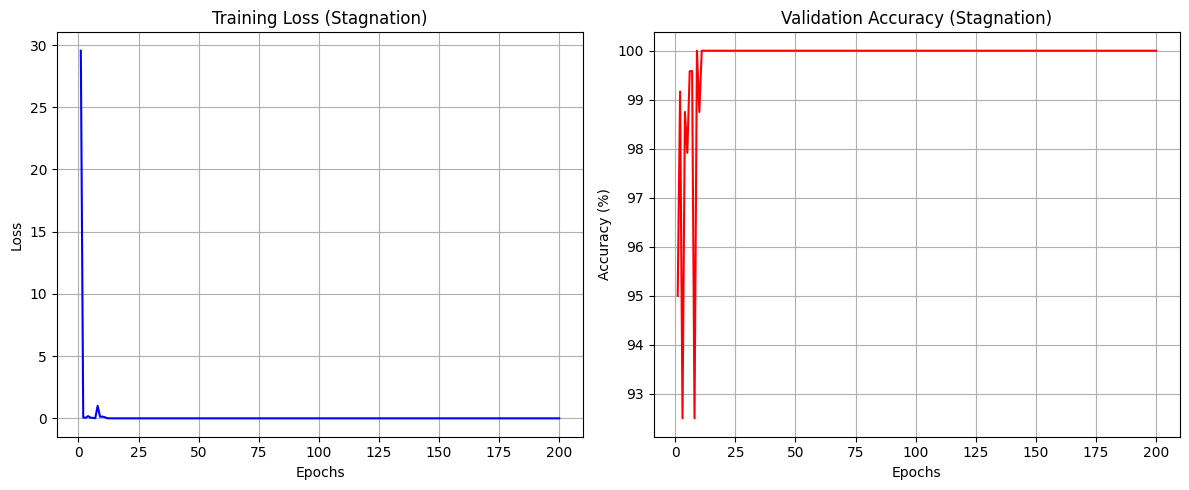

In [ ]:
# 학습 정체 시각화

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history['train_loss'], label='Train Loss', color='blue')
plt.title('Training Loss (Stagnation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history['test_accuracy'], label='Test Accuracy', color='red')
plt.title('Validation Accuracy (Stagnation)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

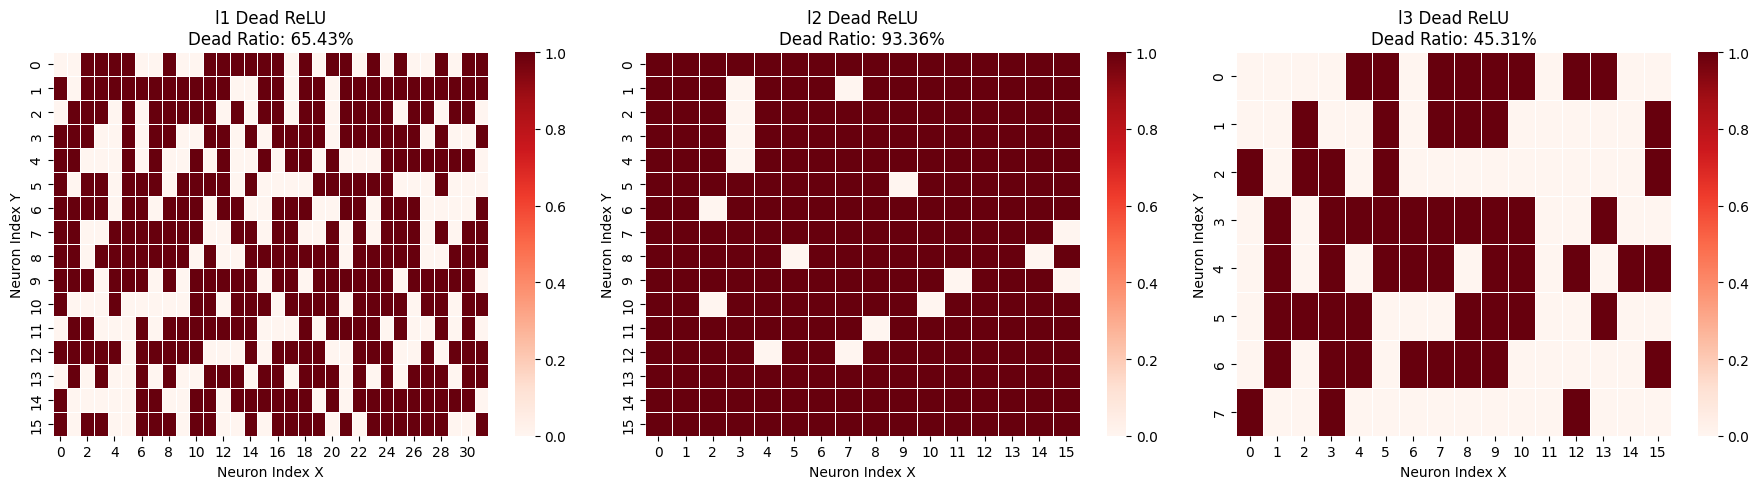

In [ ]:
# 레이어 별 dead relu 정도 파악
visualize_dead_relu(model, test_loader)

leaky_relu

In [ ]:
# B-2 번 실험 : Leaky_ReLU 사용

# 모델 정의
# 신경망 구조: 입력층(784개) → 은닉층(512개, leaky_ReLU) → 은닉층(256개, leaky_ReLU) -> 은닉층(128개, leaky_ReLU) -> output

class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(DeepMLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)  # 활성화 함수로 leaky_ReLU를 사용

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, hidden3)
        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
      self.l1 = self.leaky_relu(self.fc1(x))
      self.l2 = self.leaky_relu(self.fc2(self.l1))
      self.l3 = self.leaky_relu(self.fc3(self.l2))

    # 추후 레이어별 기여도를 뽑기 위함.  activation값 * gradient를 계산하여금 기여도를 계산.
      if self.l1.requires_grad:
          self.l1.retain_grad()
      if self.l2.requires_grad:
          self.l2.retain_grad()
      if self.l3.requires_grad:
          self.l3.retain_grad()

      x = self.fc4(self.l3)
      return x

In [ ]:
# 모델 및 최적화 알고리즘 설정
# 모델을 GPU로 이동(.to(device))시켜 빠르게 학습할 수 있도록 함.
model = DeepMLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)

# 손실함수 및 옵티마이저 설정
loss_fn = nn.CrossEntropyLoss()  # 내부적으로 log(softmax()) 계산을 포함하고 있음.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

In [ ]:
# 모델 학습
# 전체 데이터셋을 반복(epoch)하면서 학습 진행

# 학습 정체 및 히트맵 출력을 위함
history = {'train_loss': [], 'test_accuracy': []}

contribution_history = {
    'l1': [],
    'l2': [],
    'l3': []
}

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    epoch_contrib_l1 = 0
    epoch_contrib_l2 = 0
    epoch_contrib_l3 = 0
    batch_count = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 순전파
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # 역전파 및 최적화
        optimizer.zero_grad()
        loss.backward()

        # -------------------------------
        # activation × gradient 계산 위치
        # -------------------------------
        with torch.no_grad():
            contrib_l1 = torch.abs(model.l1 * model.l1.grad).mean().item()
            contrib_l2 = torch.abs(model.l2 * model.l2.grad).mean().item()
            contrib_l3 = torch.abs(model.l3 * model.l3.grad).mean().item()

            epoch_contrib_l1 += contrib_l1
            epoch_contrib_l2 += contrib_l2
            epoch_contrib_l3 += contrib_l3
            batch_count += 1

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    avg_contrib_l1 = epoch_contrib_l1 / batch_count
    avg_contrib_l2 = epoch_contrib_l2 / batch_count
    avg_contrib_l3 = epoch_contrib_l3 / batch_count

    contribution_history['l1'].append(avg_contrib_l1)
    contribution_history['l2'].append(avg_contrib_l2)
    contribution_history['l3'].append(avg_contrib_l3)

    # 검증 데이터셋 평가
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f'Epoch [{epoch+1}/{num_epochs}], '
        f'Loss: {avg_loss:.4f}, '
        f'Accuracy: {accuracy:.2f}%, '
        f'C1: {avg_contrib_l1:.6f}, '
        f'C2: {avg_contrib_l2:.6f}, '
        f'C3: {avg_contrib_l3:.6f}'
    )

    history['train_loss'].append(avg_loss)
    history['test_accuracy'].append(accuracy)

    scheduler.step(avg_loss)

Epoch [1/200], Loss: 52.1660, Accuracy: 84.17%, C1: 0.004905, C2: 0.011733, C3: 0.026296
Epoch [2/200], Loss: 1.6155, Accuracy: 90.00%, C1: 0.000489, C2: 0.001106, C3: 0.008365
Epoch [3/200], Loss: 0.3363, Accuracy: 100.00%, C1: 0.000136, C2: 0.000267, C3: 0.001561
Epoch [4/200], Loss: 0.0087, Accuracy: 99.58%, C1: 0.000015, C2: 0.000018, C3: 0.000063
Epoch [5/200], Loss: 0.0087, Accuracy: 100.00%, C1: 0.000010, C2: 0.000012, C3: 0.000049
Epoch [6/200], Loss: 0.0018, Accuracy: 100.00%, C1: 0.000003, C2: 0.000004, C3: 0.000015
Epoch [7/200], Loss: 0.0010, Accuracy: 100.00%, C1: 0.000002, C2: 0.000002, C3: 0.000007
Epoch [8/200], Loss: 0.0009, Accuracy: 100.00%, C1: 0.000002, C2: 0.000002, C3: 0.000007
Epoch [9/200], Loss: 0.0008, Accuracy: 100.00%, C1: 0.000001, C2: 0.000002, C3: 0.000006
Epoch [10/200], Loss: 0.0008, Accuracy: 100.00%, C1: 0.000001, C2: 0.000002, C3: 0.000006
Epoch [11/200], Loss: 0.0006, Accuracy: 100.00%, C1: 0.000001, C2: 0.000001, C3: 0.000005
Epoch [12/200], Loss:

In [ ]:
# Layer별 출력값 시각화
# 학습이 끝난 후, test 데이터 중 일부를 모델에 넣고
# 각 은닉층의 activation 값을 matplotlib으로 시각화

import matplotlib.pyplot as plt

model.eval()

# test_loader에서 배치 하나 가져오기
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

# forward 과정에서 저장된 layer 출력값 가져오기
l1_output = model.l1.detach().cpu()
l2_output = model.l2.detach().cpu()
l3_output = model.l3.detach().cpu()

print("Layer 1 output shape:", l1_output.shape)
print("Layer 2 output shape:", l2_output.shape)
print("Layer 3 output shape:", l3_output.shape)

Layer 1 output shape: torch.Size([32, 512])
Layer 2 output shape: torch.Size([32, 256])
Layer 3 output shape: torch.Size([32, 128])


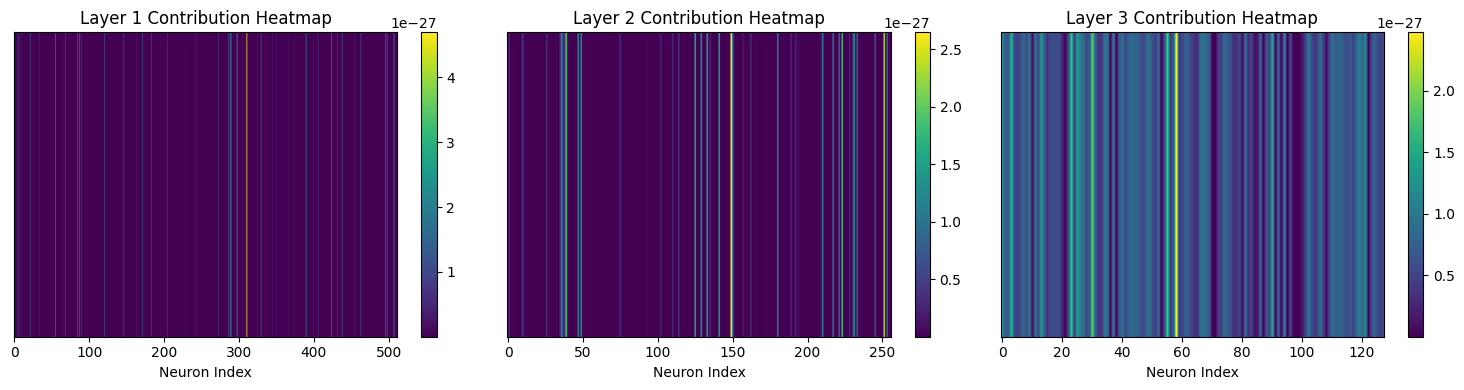

In [ ]:
# 레이어 별 기여도 히트맵 출력

model.train()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = loss_fn(outputs, labels)

optimizer.zero_grad()
loss.backward()

contrib_l1 = torch.abs(model.l1 * model.l1.grad).detach().cpu()
contrib_l2 = torch.abs(model.l2 * model.l2.grad).detach().cpu()
contrib_l3 = torch.abs(model.l3 * model.l3.grad).detach().cpu()

sample_idx = 0

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(contrib_l1[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 1 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(contrib_l2[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 2 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(contrib_l3[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 3 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.tight_layout()
plt.show()

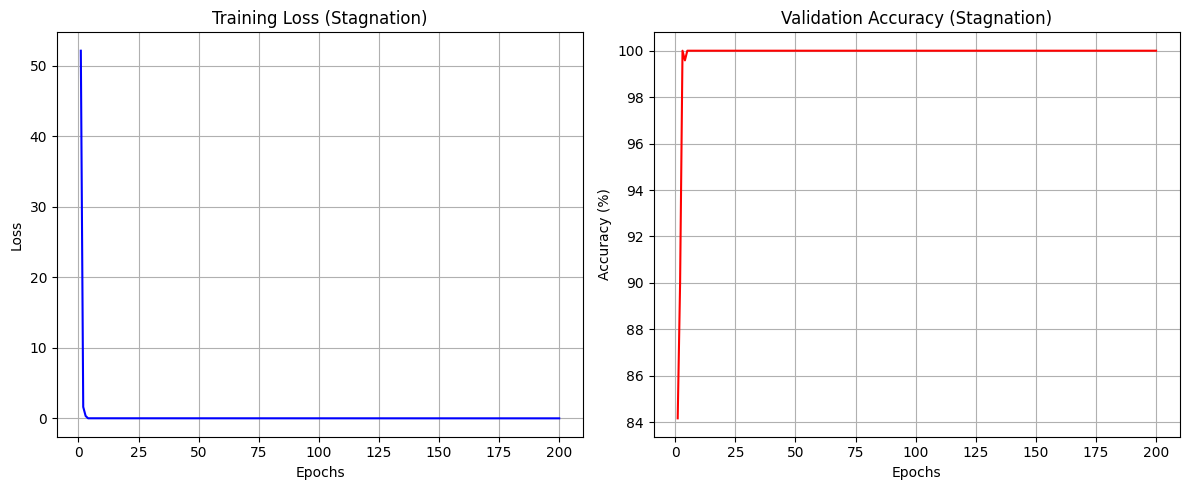

In [ ]:
# 학습 정체 시각화

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history['train_loss'], label='Train Loss', color='blue')
plt.title('Training Loss (Stagnation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history['test_accuracy'], label='Test Accuracy', color='red')
plt.title('Validation Accuracy (Stagnation)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

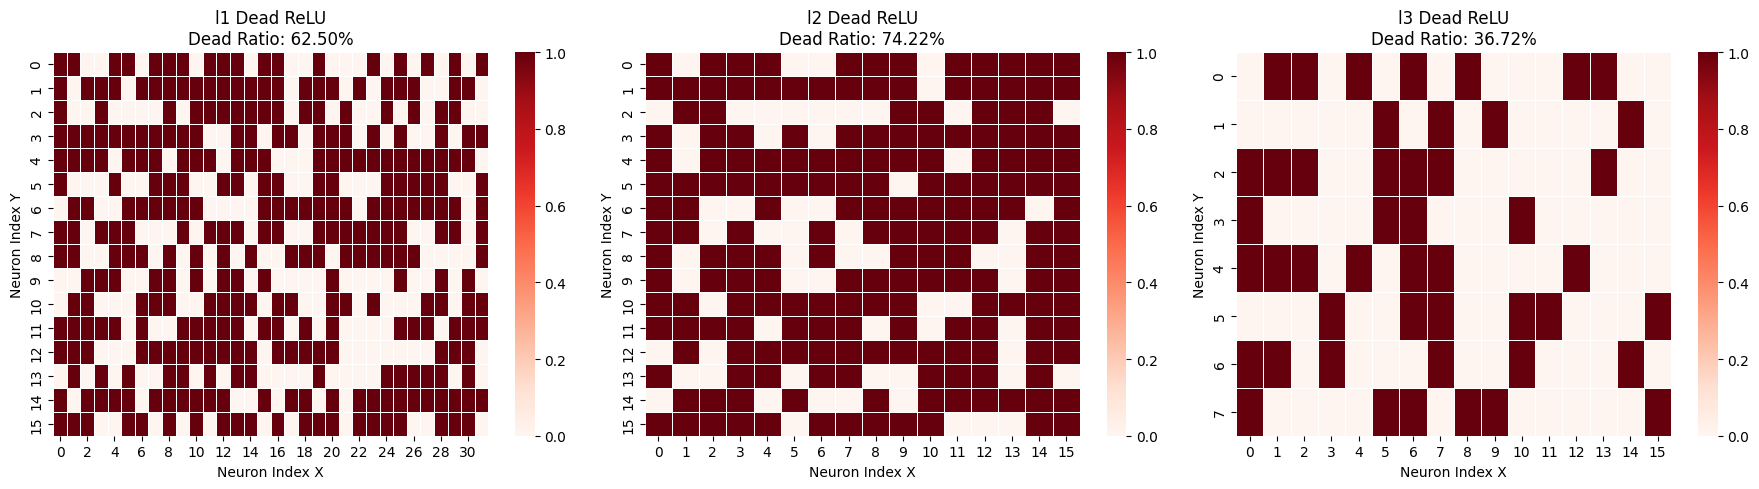

In [ ]:
# 레이어 별 dead relu 정도 파악
visualize_dead_relu(model, test_loader)

Sigmoid

In [ ]:
# B-3 번 실험 : Sigmoid 사용

# 모델 정의
# 신경망 구조: 입력층(784개) → 은닉층(512개, leaky_ReLU) → 은닉층(256개, leaky_ReLU) -> 은닉층(128개, leaky_ReLU) -> output

class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(DeepMLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.sigmoid = nn.Sigmoid() # 활성화 함수로 leaky_ReLU를 사용

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, hidden3)
        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
      self.l1 = self.sigmoid(self.fc1(x))
      self.l2 = self.sigmoid(self.fc2(self.l1))
      self.l3 = self.sigmoid(self.fc3(self.l2))

    # 추후 레이어별 기여도를 뽑기 위함.  activation값 * gradient를 계산하여금 기여도를 계산.
      if self.l1.requires_grad:
          self.l1.retain_grad()
      if self.l2.requires_grad:
          self.l2.retain_grad()
      if self.l3.requires_grad:
          self.l3.retain_grad()

      x = self.fc4(self.l3)
      return x

In [ ]:
# 모델 및 최적화 알고리즘 설정
# 모델을 GPU로 이동(.to(device))시켜 빠르게 학습할 수 있도록 함.
model = DeepMLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)

# 손실함수 및 옵티마이저 설정
loss_fn = nn.CrossEntropyLoss()  # 내부적으로 log(softmax()) 계산을 포함하고 있음.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

In [ ]:

# 공통과제 3번 위해 추가적으로 실습 진행 -> 초기, 중간, 후기 activation 확
activation_snapshots = {
    'early': {'l1': None, 'l2': None, 'l3': None},
    'middle': {'l1': None, 'l2': None, 'l3': None},
    'late': {'l1': None, 'l2': None, 'l3': None}
}

snapshot_epochs = {
    1: 'early',
    num_epochs // 2: 'middle',
    num_epochs: 'late'
}

In [ ]:
# 모델 학습
# 전체 데이터셋을 반복(epoch)하면서 학습 진행

# 학습 정체 및 히트맵 출력을 위함
history = {'train_loss': [], 'test_accuracy': []}

contribution_history = {
    'l1': [],
    'l2': [],
    'l3': []
}

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    epoch_contrib_l1 = 0
    epoch_contrib_l2 = 0
    epoch_contrib_l3 = 0
    batch_count = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 순전파
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # 역전파 및 최적화
        optimizer.zero_grad()
        loss.backward()

        # -------------------------------
        # activation × gradient 계산 위치
        # -------------------------------
        with torch.no_grad():
            contrib_l1 = torch.abs(model.l1 * model.l1.grad).mean().item()
            contrib_l2 = torch.abs(model.l2 * model.l2.grad).mean().item()
            contrib_l3 = torch.abs(model.l3 * model.l3.grad).mean().item()

            epoch_contrib_l1 += contrib_l1
            epoch_contrib_l2 += contrib_l2
            epoch_contrib_l3 += contrib_l3
            batch_count += 1

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    avg_contrib_l1 = epoch_contrib_l1 / batch_count
    avg_contrib_l2 = epoch_contrib_l2 / batch_count
    avg_contrib_l3 = epoch_contrib_l3 / batch_count

    contribution_history['l1'].append(avg_contrib_l1)
    contribution_history['l2'].append(avg_contrib_l2)
    contribution_history['l3'].append(avg_contrib_l3)

    # 검증 데이터셋 평가
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f'Epoch [{epoch+1}/{num_epochs}], '
        f'Loss: {avg_loss:.4f}, '
        f'Accuracy: {accuracy:.2f}%, '
        f'C1: {avg_contrib_l1:.6f}, '
        f'C2: {avg_contrib_l2:.6f}, '
        f'C3: {avg_contrib_l3:.6f}'
    )

    history['train_loss'].append(avg_loss)
    history['test_accuracy'].append(accuracy)

    # -------------------------------
    # 초반 / 중반 / 후반 Activation 저장
    # -------------------------------
    if (epoch + 1) in snapshot_epochs:
        phase = snapshot_epochs[epoch + 1]

        model.eval()
        all_l1 = []
        all_l2 = []
        all_l3 = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)

                outputs = model(images)

                all_l1.append(model.l1.detach().cpu())
                all_l2.append(model.l2.detach().cpu())
                all_l3.append(model.l3.detach().cpu())

        activation_snapshots[phase]['l1'] = torch.cat(all_l1, dim=0)
        activation_snapshots[phase]['l2'] = torch.cat(all_l2, dim=0)
        activation_snapshots[phase]['l3'] = torch.cat(all_l3, dim=0)

        print(f"{phase} activation saved at epoch {epoch+1}")

    scheduler.step(avg_loss)



Epoch [1/200], Loss: 1.4653, Accuracy: 47.50%, C1: 0.000000, C2: 0.000001, C3: 0.000400
early activation saved at epoch 1
Epoch [2/200], Loss: 0.7819, Accuracy: 47.50%, C1: 0.000000, C2: 0.000000, C3: 0.000258
Epoch [3/200], Loss: 0.8497, Accuracy: 47.50%, C1: 0.000000, C2: 0.000000, C3: 0.000271
Epoch [4/200], Loss: 0.8698, Accuracy: 52.50%, C1: 0.000000, C2: 0.000000, C3: 0.000272
Epoch [5/200], Loss: 0.8074, Accuracy: 52.50%, C1: 0.000000, C2: 0.000000, C3: 0.000261
Epoch [6/200], Loss: 0.7966, Accuracy: 52.50%, C1: 0.000000, C2: 0.000000, C3: 0.000263
Epoch [7/200], Loss: 0.7069, Accuracy: 47.50%, C1: 0.000000, C2: 0.000000, C3: 0.000248
Epoch [8/200], Loss: 0.7144, Accuracy: 52.50%, C1: 0.000000, C2: 0.000000, C3: 0.000250
Epoch [9/200], Loss: 0.7787, Accuracy: 52.50%, C1: 0.000000, C2: 0.000000, C3: 0.000260
Epoch [10/200], Loss: 0.7358, Accuracy: 47.50%, C1: 0.000000, C2: 0.000000, C3: 0.000253
Epoch [11/200], Loss: 0.7111, Accuracy: 47.50%, C1: 0.000000, C2: 0.000000, C3: 0.000

In [ ]:
# Layer별 출력값 시각화
# 학습이 끝난 후, test 데이터 중 일부를 모델에 넣고
# 각 은닉층의 activation 값을 matplotlib으로 시각화

import matplotlib.pyplot as plt

model.eval()

# test_loader에서 배치 하나 가져오기
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

# forward 과정에서 저장된 layer 출력값 가져오기
l1_output = model.l1.detach().cpu()
l2_output = model.l2.detach().cpu()
l3_output = model.l3.detach().cpu()

print("Layer 1 output shape:", l1_output.shape)
print("Layer 2 output shape:", l2_output.shape)
print("Layer 3 output shape:", l3_output.shape)

Layer 1 output shape: torch.Size([32, 512])
Layer 2 output shape: torch.Size([32, 256])
Layer 3 output shape: torch.Size([32, 128])


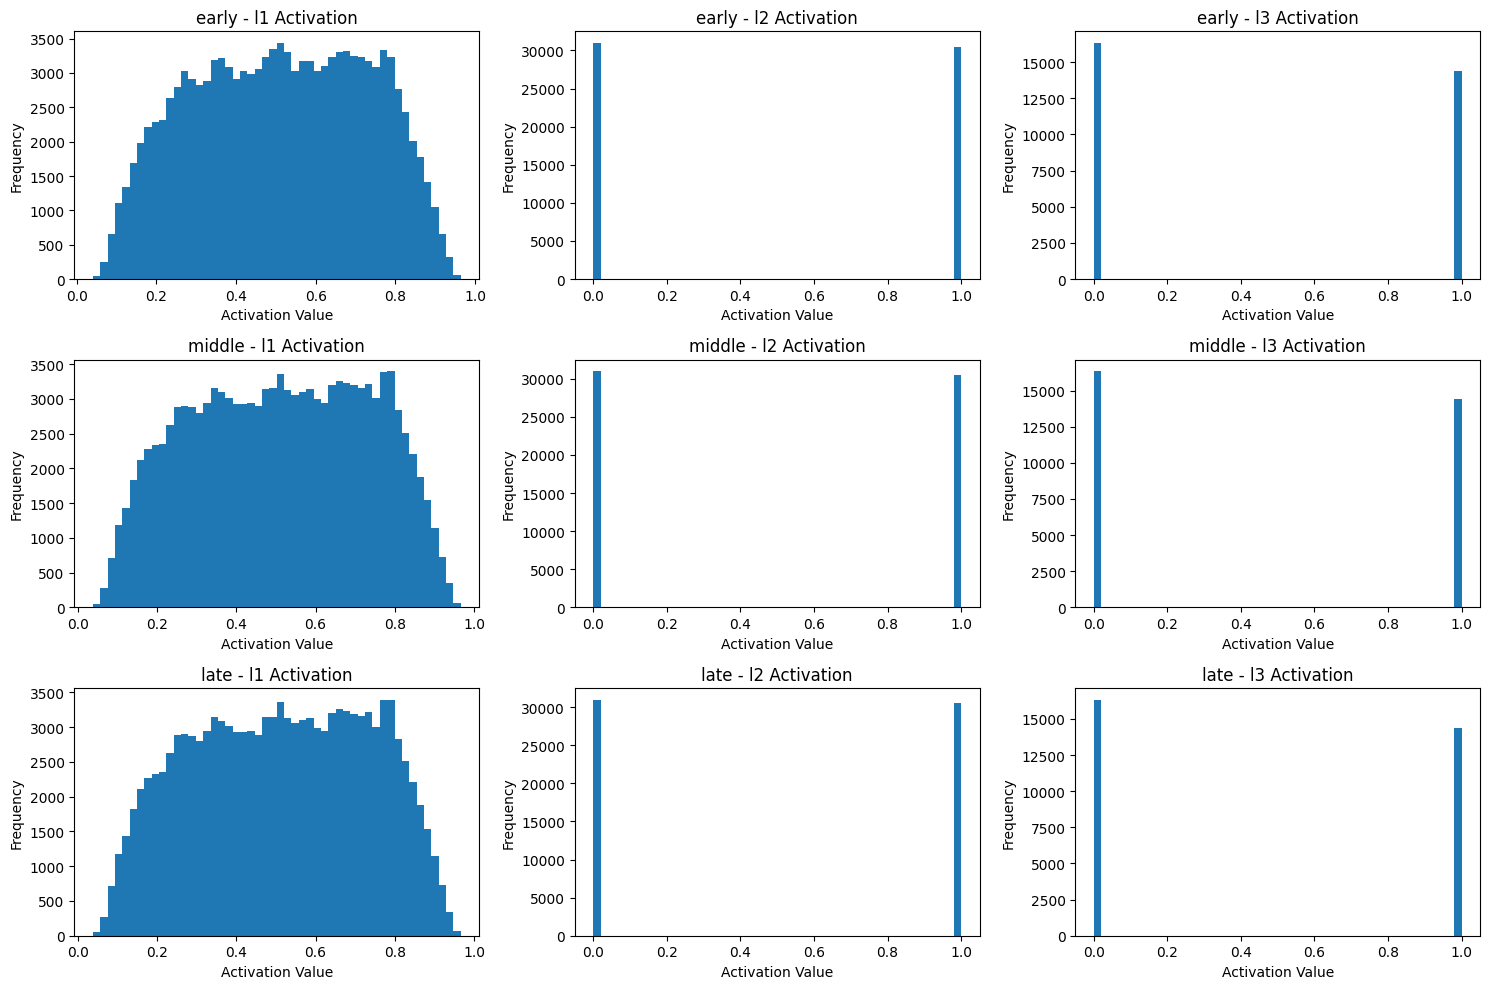

In [ ]:
# 공통과제 3번 위함 -> layer별 초기, 중기, 후기의 activation 확인
import matplotlib.pyplot as plt

phases = ['early', 'middle', 'late']
layers = ['l1', 'l2', 'l3']

plt.figure(figsize=(15, 10))

plot_idx = 1

for phase in phases:
    for layer in layers:
        act = activation_snapshots[phase][layer]

        plt.subplot(3, 3, plot_idx)
        plt.hist(act.numpy().flatten(), bins=50)
        plt.title(f'{phase} - {layer} Activation')
        plt.xlabel('Activation Value')
        plt.ylabel('Frequency')

        plot_idx += 1

plt.tight_layout()
plt.show()

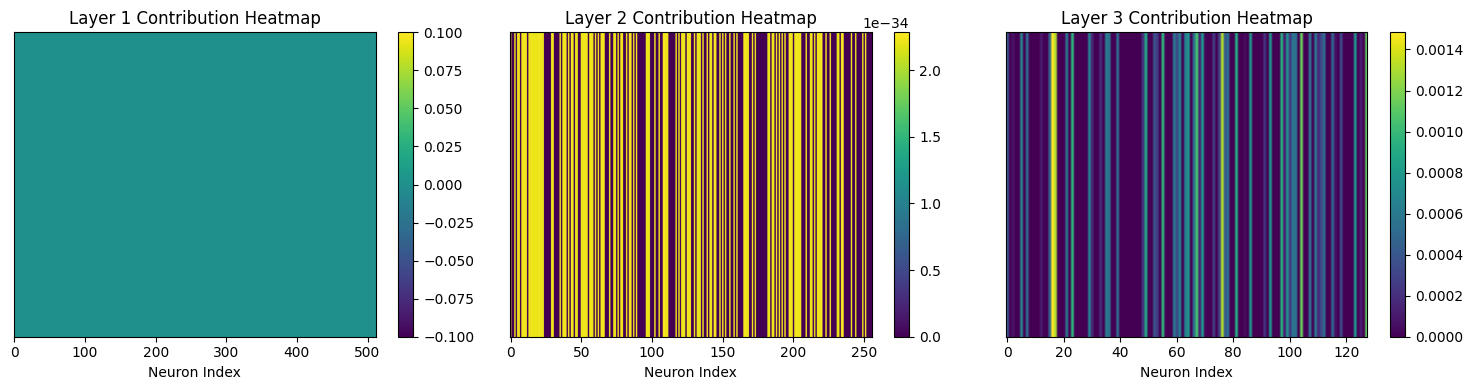

In [ ]:
# 레이어 별 기여도 히트맵 출력

model.train()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = loss_fn(outputs, labels)

optimizer.zero_grad()
loss.backward()

contrib_l1 = torch.abs(model.l1 * model.l1.grad).detach().cpu()
contrib_l2 = torch.abs(model.l2 * model.l2.grad).detach().cpu()
contrib_l3 = torch.abs(model.l3 * model.l3.grad).detach().cpu()

sample_idx = 0

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(contrib_l1[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 1 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(contrib_l2[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 2 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(contrib_l3[sample_idx].numpy().reshape(1, -1), aspect='auto', cmap='viridis')
plt.title("Layer 3 Contribution Heatmap")
plt.xlabel("Neuron Index")
plt.yticks([])
plt.colorbar()

plt.tight_layout()
plt.show()

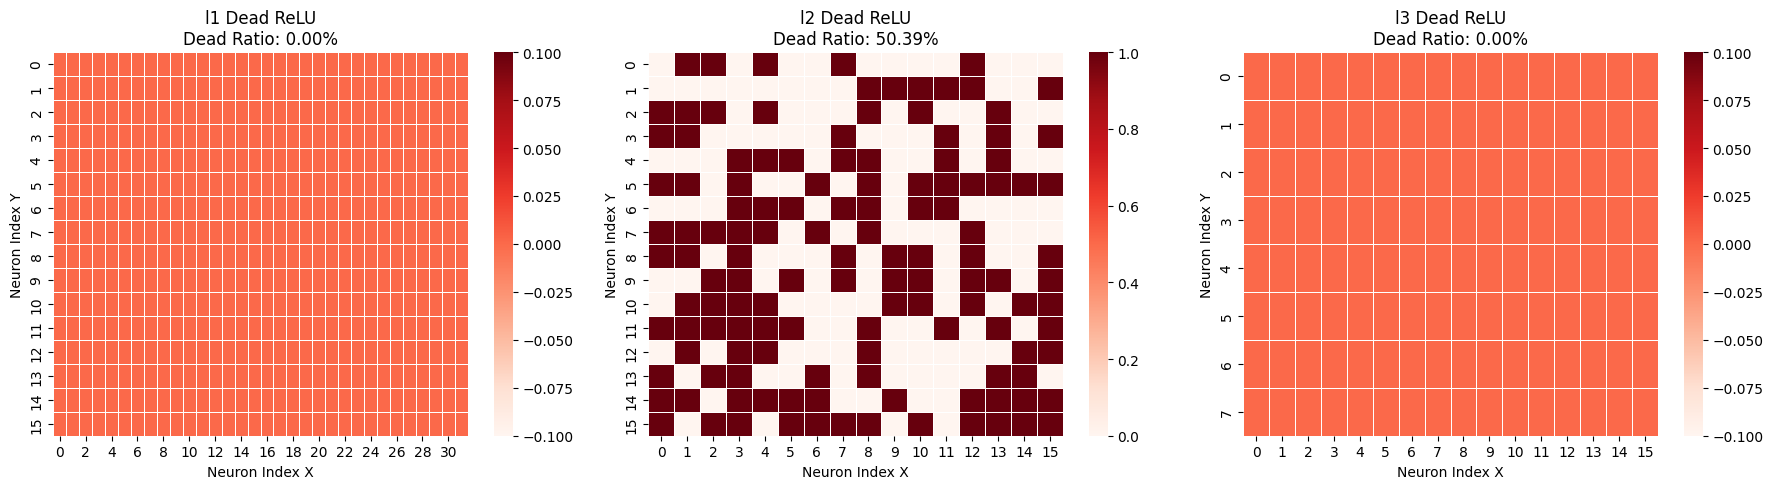

In [ ]:
# 레이어 별 dead relu 정도 파악
visualize_dead_relu(model, test_loader)

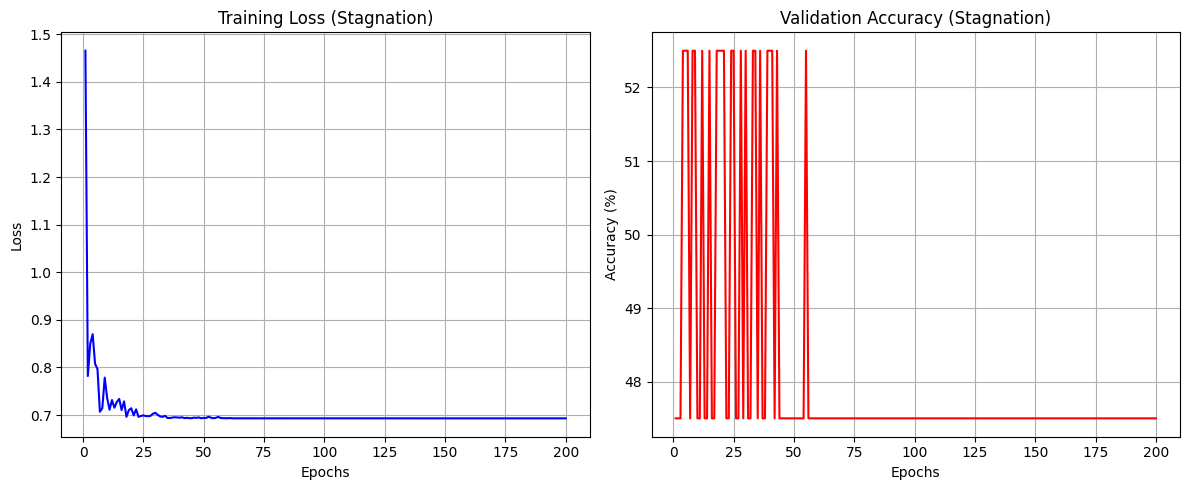

In [ ]:
# 학습 정체 시각화

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history['train_loss'], label='Train Loss', color='blue')
plt.title('Training Loss (Stagnation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history['test_accuracy'], label='Test Accuracy', color='red')
plt.title('Validation Accuracy (Stagnation)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

## [실험 C] 최적화 알고리즘 비교 : SGD, SGD+Momentum, Adam

### 1) 실험 목표
  - SGD, SGD+Momentum, Adam의 성능 비교
  - 학습률 변화가 미치는 영향 분석 (0.1, 0.01, 0.001)

### 2) 추천 데이터셋: Fashion-MNIST, Digits Dataset

### 3) 실험 조건
  - 동일한 네트워크, 손실함수, 데이터셋
  - 학습률에 따른 3개의 optimizer 성능 비교 (표로 정리)
  - Learning rate를 지수 감소 (Exponential Decay) 적용하여 실험  

     scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

### 4) 분석 포인트
  - Overshooting, 느린 수렴, 안정성 확인
  - 학습률 변화에 따른 Loss 곡선과 Gradient 흐름 분석

데이터셋 정의


In [ ]:
# 1) Fashioln_mnist 데이터셋 로드
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 전처리 정의: 이미지를 텐서로 변환하고 정규화 (평균 0.5, 표준편차 0.5)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Fashion-MNIST 데이터셋 다운로드 및 로드
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [ ]:
# 하이퍼 파라미터 설정 : 모델의 구조와 학습 조건을 정의하는 핵심 변수들.
input_size = 784      # MNIST 이미지 크기 (28*28 픽셀)
input_size = 784      # MNIST 이미지 크기 (28*28 픽셀)
hidden_size1 = 512     # 은닉층의 노드 수
hidden_size2 = 256
hidden_size3 = 128
num_classes = 10      # 숫자 클래스 (0~9)
num_classes = 10      # 숫자 클래스 (0~9)
num_epochs = 20       # 학습 횟수
batch_size = 128      # 한 번에 처리하는 데이터 개수
lr_list = [0.1, 0.01, 0.001] # 학습률 (너무 크면 발산, 너무 작으면 느린 학습) <<<<< 변경 필요
lr_results = {}

In [ ]:
# 3. DataLoader 설정
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")

학습 데이터 개수: 60000
테스트 데이터 개수: 10000


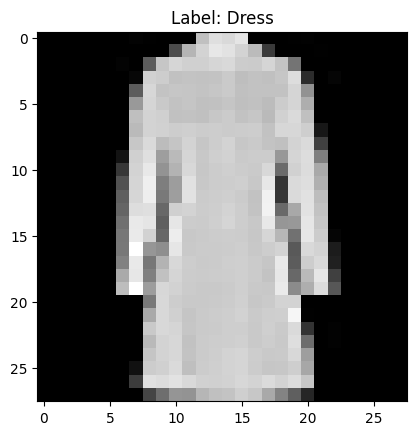

In [ ]:
# 3) 데이터 확인
import matplotlib.pyplot as plt

# 첫 번째 배치 데이터 가져오기
images, labels = next(iter(train_loader))

# 클래스 레이블 매핑
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 이미지 시각화
plt.imshow(images[0].numpy().squeeze(), cmap='gray')
plt.title(f'Label: {classes[labels[0]]}')
plt.show()

In [ ]:
from tensorflow.keras.optimizers import Adam, SGD

실험

In [ ]:
# 실험 C-1 SGD optimizer 사용 시 learning_rate 따른 학습 변화추이 분석
# 모델 정의
# 신경망 구조: 입력층(784개) → 은닉층(512개, ReLU) → 은닉층(256개, ReLU) → 은닉층(128, ReLU) →  출력층(10개)

class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden2, hidden3)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.fc4(x)
        return x

model = MLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)

In [ ]:
# 실험 C-1 SGD optimizer 사용 시 learning_rate에 따른 학습 변화 추이 분석

lr_list = [0.1, 0.01, 0.001]
lr_results = {}

# learning rate를 변경시키며 분석해야 하므로, 리스트 형태로 선언하고 하나씩 끌고왔음
for lr in lr_list:
    print(f"\n🚀 Fashion-MNIST [C-1 SGD] 학습률 {lr} 실험 시작...")

    # 1. 은닉층 3개짜리 MLP 모델 선언
    model = MLP(
        input_size,
        hidden_size1,
        hidden_size2,
        hidden_size3,
        num_classes
    ).to(device)

    # 2. 손실함수와 SGD optimizer 세팅
    # 세 번의 실험을 같은 for문에서 실행함. 따라서, 내부에서 optimizer와 loss function, scheduler을 초기화해야
    # 정상적으로 학습됨. 외부에 정의 시 같은 loss fn, optimizer, scheduler을 공유하므로 정상적으로 학습 x
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # 3. Exponential Learning Rate Scheduler 적용
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=0.9
    )

    train_losses = []
    test_accuracies = []
    lr_history = []

    # --- 학습 루프 ---
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.reshape(-1, 28 * 28).to(device)
            labels = labels.to(device)

            # 순전파
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            # 역전파 및 최적화
            optimizer.zero_grad()
            loss.backward()

            # Gradient exploding 방지용 clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # 검증 데이터셋 평가
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.reshape(-1, 28 * 28).to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        # 현재 learning rate 저장
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        lr_history.append(current_lr)

        print(
            f"   👉 [Epoch {epoch+1}/{num_epochs}] "
            f"Loss: {avg_loss:.4f}, "
            f"Accuracy: {accuracy:.2f}%, "
            f"Current LR: {current_lr:.6f}"
        )

        # epoch 끝난 뒤 learning rate 감소
        scheduler.step()

    # 결과 누적
    lr_results[lr] = {
        'loss': train_losses,
        'accuracy': test_accuracies,
        'lr': lr_history
    }

    print(f"✅ 학습률 {lr} 실험 종료! 최종 검증 정확도: {test_accuracies[-1]:.2f}%")


🚀 Fashion-MNIST [C-1 SGD] 학습률 0.1 실험 시작...
   👉 [Epoch 1/20] Loss: 0.7728, Accuracy: 79.53%, Current LR: 0.100000
   👉 [Epoch 2/20] Loss: 0.4735, Accuracy: 83.02%, Current LR: 0.090000
   👉 [Epoch 3/20] Loss: 0.4124, Accuracy: 84.45%, Current LR: 0.081000
   👉 [Epoch 4/20] Loss: 0.3781, Accuracy: 84.94%, Current LR: 0.072900
   👉 [Epoch 5/20] Loss: 0.3530, Accuracy: 85.62%, Current LR: 0.065610
   👉 [Epoch 6/20] Loss: 0.3329, Accuracy: 86.69%, Current LR: 0.059049
   👉 [Epoch 7/20] Loss: 0.3175, Accuracy: 86.99%, Current LR: 0.053144
   👉 [Epoch 8/20] Loss: 0.3041, Accuracy: 86.95%, Current LR: 0.047830
   👉 [Epoch 9/20] Loss: 0.2933, Accuracy: 87.39%, Current LR: 0.043047
   👉 [Epoch 10/20] Loss: 0.2823, Accuracy: 87.52%, Current LR: 0.038742
   👉 [Epoch 11/20] Loss: 0.2745, Accuracy: 87.54%, Current LR: 0.034868
   👉 [Epoch 12/20] Loss: 0.2667, Accuracy: 87.73%, Current LR: 0.031381
   👉 [Epoch 13/20] Loss: 0.2595, Accuracy: 88.22%, Current LR: 0.028243
   👉 [Epoch 14/20] Loss: 0.25

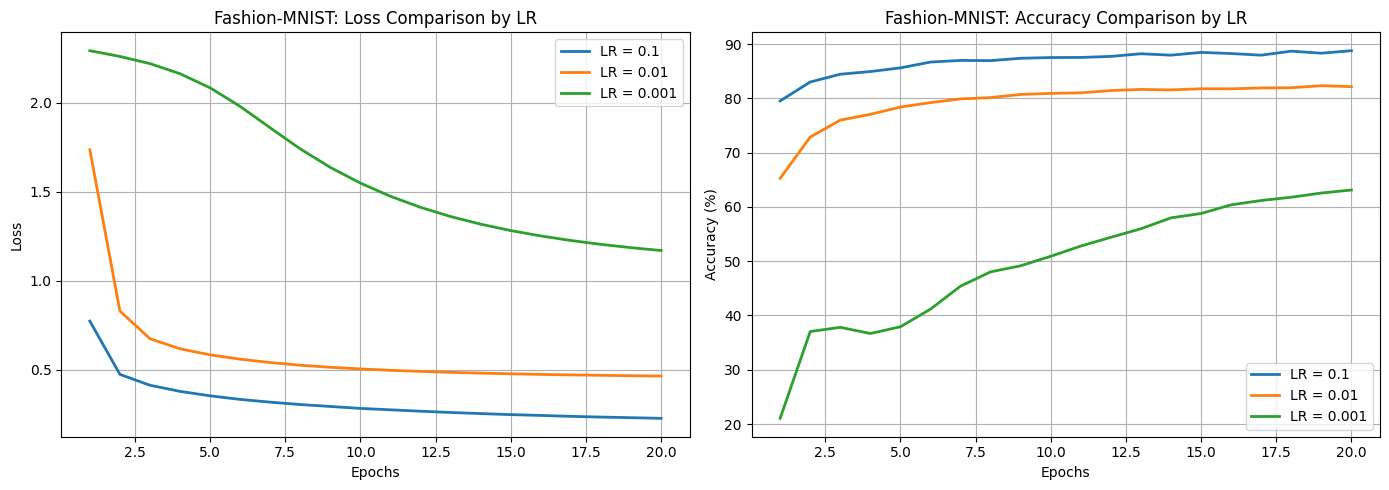

In [ ]:
import matplotlib.pyplot as plt

# 결과 시각화
plt.figure(figsize=(14, 5))

# 1. Loss 비교 그래프
plt.subplot(1, 2, 1)
for lr, res in lr_results.items():
    plt.plot(range(1, num_epochs + 1), res['loss'], label=f'LR = {lr}', linewidth=2)
plt.title('Fashion-MNIST: Loss Comparison by LR')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy 비교 그래프
plt.subplot(1, 2, 2)
for lr, res in lr_results.items():
    plt.plot(range(1, num_epochs + 1), res['accuracy'], label=f'LR = {lr}', linewidth=2)
plt.title('Fashion-MNIST: Accuracy Comparison by LR')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 실험 C-2 SGD optimizer 사용 시 learning_rate 따른 학습 변화추이 분석
# 모델 정의
# 신경망 구조: 입력층(784개) → 은닉층(512개, ReLU) → 은닉층(256개, ReLU) → 은닉층(128, ReLU) →  출력층(10개)

class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden2, hidden3)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.fc4(x)
        return x

model = MLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)


In [ ]:
# 실험 C-2 SGD optimizer + Momentum 사용 시 learning_rate에 따른 학습 변화 추이 분석

lr_list = [0.1, 0.01, 0.001]
lr_results = {}

# learning rate를 변경시키며 분석해야 하므로, 리스트 형태로 선언하고 하나씩 끌고왔음
for lr in lr_list:
    print(f"\n🚀 Fashion-MNIST [C-2 SGD + Momentum] 학습률 {lr} 실험 시작...")

    # 1. 은닉층 3개짜리 MLP 모델 선언
    model = MLP(
        input_size,
        hidden_size1,
        hidden_size2,
        hidden_size3,
        num_classes
    ).to(device)

    # 2. 손실함수와 SGD optimizer 세팅
    # 세 번의 실험을 같은 for문에서 실행함. 따라서, 내부에서 optimizer와 loss function, scheduler을 초기화해야
    # 정상적으로 학습됨. 외부에 정의 시 같은 loss fn, optimizer, scheduler을 공유하므로 정상적으로 학습 x
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9) # Momentum 추가

    # 3. Exponential Learning Rate Scheduler 적용
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=0.9
    )

    train_losses = []
    test_accuracies = []
    lr_history = []

    # --- 학습 루프 ---
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.reshape(-1, 28 * 28).to(device)
            labels = labels.to(device)

            # 순전파
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            # 역전파 및 최적화
            optimizer.zero_grad()
            loss.backward()

            # Gradient exploding 방지용 clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # 검증 데이터셋 평가
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.reshape(-1, 28 * 28).to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        # 현재 learning rate 저장
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        lr_history.append(current_lr)

        print(
            f"   👉 [Epoch {epoch+1}/{num_epochs}] "
            f"Loss: {avg_loss:.4f}, "
            f"Accuracy: {accuracy:.2f}%, "
            f"Current LR: {current_lr:.6f}"
        )

        # epoch 끝난 뒤 learning rate 감소
        scheduler.step()

    # 결과 누적
    lr_results[lr] = {
        'loss': train_losses,
        'accuracy': test_accuracies,
        'lr': lr_history
    }

    print(f"✅ 학습률 {lr} 실험 종료! 최종 검증 정확도: {test_accuracies[-1]:.2f}%")


🚀 Fashion-MNIST [C-2 SGD + Momentum] 학습률 0.1 실험 시작...
   👉 [Epoch 1/20] Loss: 0.6084, Accuracy: 82.74%, Current LR: 0.100000
   👉 [Epoch 2/20] Loss: 0.4190, Accuracy: 83.82%, Current LR: 0.090000
   👉 [Epoch 3/20] Loss: 0.3626, Accuracy: 85.76%, Current LR: 0.081000
   👉 [Epoch 4/20] Loss: 0.3315, Accuracy: 86.39%, Current LR: 0.072900
   👉 [Epoch 5/20] Loss: 0.3001, Accuracy: 87.10%, Current LR: 0.065610
   👉 [Epoch 6/20] Loss: 0.2758, Accuracy: 87.46%, Current LR: 0.059049
   👉 [Epoch 7/20] Loss: 0.2590, Accuracy: 87.63%, Current LR: 0.053144
   👉 [Epoch 8/20] Loss: 0.2393, Accuracy: 88.81%, Current LR: 0.047830
   👉 [Epoch 9/20] Loss: 0.2248, Accuracy: 87.99%, Current LR: 0.043047
   👉 [Epoch 10/20] Loss: 0.2063, Accuracy: 88.30%, Current LR: 0.038742
   👉 [Epoch 11/20] Loss: 0.1935, Accuracy: 88.95%, Current LR: 0.034868
   👉 [Epoch 12/20] Loss: 0.1823, Accuracy: 89.22%, Current LR: 0.031381
   👉 [Epoch 13/20] Loss: 0.1678, Accuracy: 89.11%, Current LR: 0.028243
   👉 [Epoch 14/20]

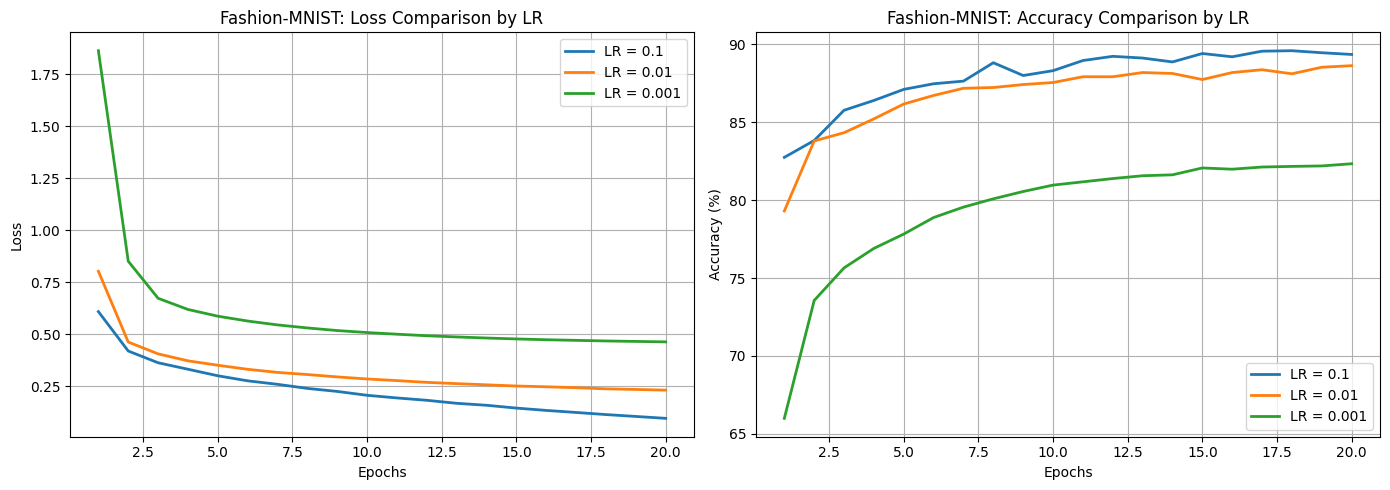

In [ ]:
import matplotlib.pyplot as plt

# 결과 시각화

plt.figure(figsize=(14, 5))

# 1. Loss 비교 그래프
plt.subplot(1, 2, 1)
for lr, res in lr_results.items():
    plt.plot(range(1, num_epochs + 1), res['loss'], label=f'LR = {lr}', linewidth=2)
plt.title('Fashion-MNIST: Loss Comparison by LR')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy 비교 그래프
plt.subplot(1, 2, 2)
for lr, res in lr_results.items():
    plt.plot(range(1, num_epochs + 1), res['accuracy'], label=f'LR = {lr}', linewidth=2)
plt.title('Fashion-MNIST: Accuracy Comparison by LR')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

의문: 왜 Momentum을 사용한 쪽이 정확도 곡선에서 더 출렁이는 것처럼 보이나??

Momentum이 성능이 나쁘다”는 뜻은 아니고, 오히려 더 공격적으로 빠르게 이동하기 때문에 test accuracy가 epoch별로 흔들려 보이는 현상

평탄한 구간에서는 빠르게 수렴하지만, 최적점 근처에서는 관성 때문에 약간 지나칠 수 있음. 이게 그래프에서 정확도가 살짝 올라갔다 내려갔다 하는 현상.

In [ ]:
# 실험 C-3 Adam optimizer 사용 시 learning_rate 따른 학습 변화추이 분석
# 모델 정의
# 신경망 구조: 입력층(784개) → 은닉층(512개, ReLU) → 은닉층(256개, ReLU) → 은닉층(128, ReLU) →  출력층(10개)

class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden2, hidden3)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(hidden3, num_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.fc4(x)
        return x

model = MLP(input_size, hidden_size1, hidden_size2, hidden_size3, num_classes).to(device)


In [ ]:
# 실험 세팅 확실하게 초기화
lr_list = [0.1, 0.01, 0.001]
lr_results = {}

# learning rate를 변경시키며 분석해야 하므로, 리스트 형태로 선언하고 하나씩 끌고왔음
for lr in lr_list:
    print(f"\n🚀 Fashion-MNIST [C-3 Adam] 학습률 {lr} 실험 시작...")

    # 1. 은닉층 3개짜리 MLP 모델 선언
    model = MLP(
        input_size,
        hidden_size1,
        hidden_size2,
        hidden_size3,
        num_classes
    ).to(device)

    # 2. 손실함수와 SGD optimizer 세팅
    # 세 번의 실험을 같은 for문에서 실행함. 따라서, 내부에서 optimizer와 loss function, scheduler을 초기화해야
    # 정상적으로 학습됨. 외부에 정의 시 같은 loss fn, optimizer, scheduler을 공유하므로 정상적으로 학습 x
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam으로 변경

    # 3. Exponential Learning Rate Scheduler 적용
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=0.9
    )

    train_losses = []
    test_accuracies = []
    lr_history = []

    # --- 학습 루프 ---
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.reshape(-1, 28 * 28).to(device)
            labels = labels.to(device)

            # 순전파
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            # 역전파 및 최적화
            optimizer.zero_grad()
            loss.backward()

            # Gradient exploding 방지용 clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # 검증 데이터셋 평가
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.reshape(-1, 28 * 28).to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        # 현재 learning rate 저장
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        lr_history.append(current_lr)

        print(
            f"   👉 [Epoch {epoch+1}/{num_epochs}] "
            f"Loss: {avg_loss:.4f}, "
            f"Accuracy: {accuracy:.2f}%, "
            f"Current LR: {current_lr:.6f}"
        )

        # epoch 끝난 뒤 learning rate 감소
        scheduler.step()

    # 결과 누적
    lr_results[lr] = {
        'loss': train_losses,
        'accuracy': test_accuracies,
        'lr': lr_history
    }

    print(f"✅ 학습률 {lr} 실험 종료! 최종 검증 정확도: {test_accuracies[-1]:.2f}%")


🚀 Fashion-MNIST [C-3 Adam] 학습률 0.1 실험 시작...
   👉 [Epoch 1/20] Loss: 105.9737, Accuracy: 10.00%, Current LR: 0.100000
   👉 [Epoch 2/20] Loss: 2.3087, Accuracy: 10.00%, Current LR: 0.090000
   👉 [Epoch 3/20] Loss: 2.3071, Accuracy: 10.00%, Current LR: 0.081000
   👉 [Epoch 4/20] Loss: 2.3071, Accuracy: 10.00%, Current LR: 0.072900
   👉 [Epoch 5/20] Loss: 2.3068, Accuracy: 10.00%, Current LR: 0.065610
   👉 [Epoch 6/20] Loss: 2.3067, Accuracy: 10.00%, Current LR: 0.059049
   👉 [Epoch 7/20] Loss: 2.3062, Accuracy: 10.00%, Current LR: 0.053144
   👉 [Epoch 8/20] Loss: 2.3057, Accuracy: 10.00%, Current LR: 0.047830
   👉 [Epoch 9/20] Loss: 2.3051, Accuracy: 10.00%, Current LR: 0.043047
   👉 [Epoch 10/20] Loss: 2.3054, Accuracy: 10.00%, Current LR: 0.038742
   👉 [Epoch 11/20] Loss: 2.3050, Accuracy: 10.00%, Current LR: 0.034868
   👉 [Epoch 12/20] Loss: 2.3047, Accuracy: 10.00%, Current LR: 0.031381
   👉 [Epoch 13/20] Loss: 2.3047, Accuracy: 10.00%, Current LR: 0.028243
   👉 [Epoch 14/20] Loss: 2

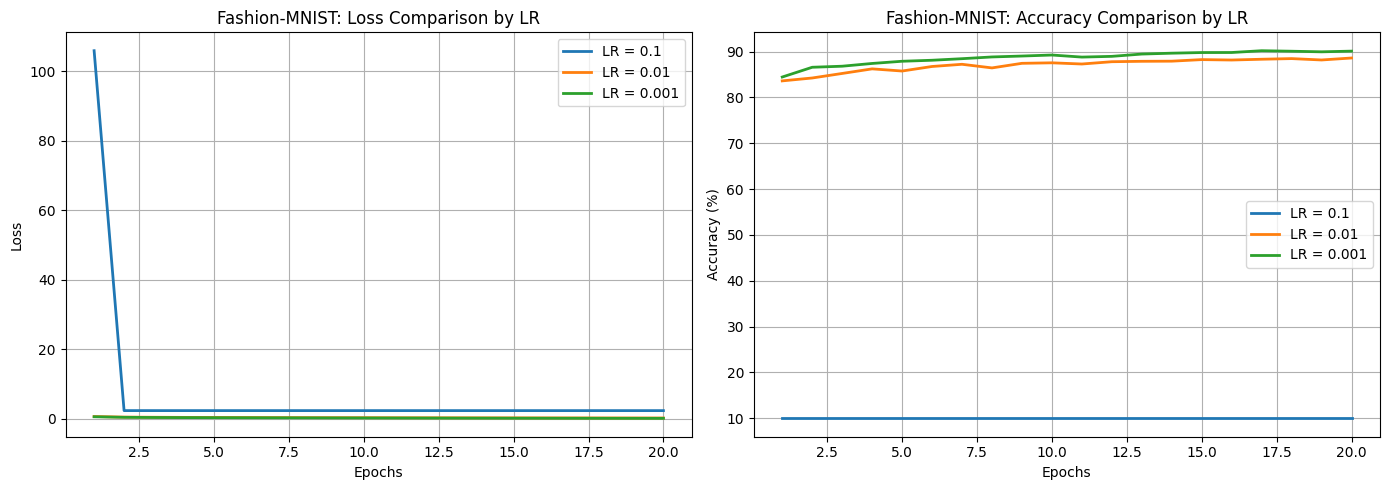

In [ ]:
import matplotlib.pyplot as plt

# 결과 시각화

plt.figure(figsize=(14, 5))

# 1. Loss 비교 그래프
plt.subplot(1, 2, 1)
for lr, res in lr_results.items():
    plt.plot(range(1, num_epochs + 1), res['loss'], label=f'LR = {lr}', linewidth=2)
plt.title('Fashion-MNIST: Loss Comparison by LR')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy 비교 그래프
plt.subplot(1, 2, 2)
for lr, res in lr_results.items():
    plt.plot(range(1, num_epochs + 1), res['accuracy'], label=f'LR = {lr}', linewidth=2)
plt.title('Fashion-MNIST: Accuracy Comparison by LR')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()